In [3]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

In [2]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 13.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 5.7 MB/s  0:00:01a 0:00:0136m0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 2.3 MB/s  0:00:00m 2.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 5.5 MB/s  0:00:005.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 4.7 MB/s  0:00:005.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 4.8 MB/s  0:00:18 eta 0:00:010:00:01
  Attempting uninstall: regex
    Found existing installation: regex 2025.9.1
    Uninstalling regex-2025.9.1:
      Successfully uninstalled regex-2025.9.1
  Attempting uninstall: click
    Found existing installation: click 8.2.1;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [click]
    Uninstalling click-8.2.1:━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [click]
      Successfully uninstalled click-8.2.137m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/9 [click]
   ━━━━━━

In [4]:
df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [5]:
df["Combined_Text"] = (
    df["Ticket_Subject"]
    + " "
    + df["Ticket_Description"]
)

df["Combined_Text"].head()

0    Hours of operation - Individual Hi Support, Wh...
1    Data not syncing - Card Hi Support, The applic...
2    2FA issues - Question Hi Support, How do I upg...
3    Login failed - Let Hi Support, The dashboard i...
4    Refund status - Attention Hi Support, I have b...
Name: Combined_Text, dtype: object

In [6]:
severity_keywords = {
    "outage":5,
    "fraud":5,
    "hacked":5,
    "stolen":5,
    "payment failed":4,
    "unauthorized":4,
    "error":3,
    "failed":3,
    "urgent":2,
    "asap":1,
    "login":1,
    "password":1
}

In [7]:
def keyword_score(text):
    text = text.lower()
    score = 0

    for word, value in severity_keywords.items():
        if word in text:
            score += value

    return score

In [8]:
df["Keyword_Score"] = df["Combined_Text"].apply(keyword_score)

df["Keyword_Score"].describe()

count    20000.000000
mean         0.984700
std          1.905557
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          7.000000
Name: Keyword_Score, dtype: float64

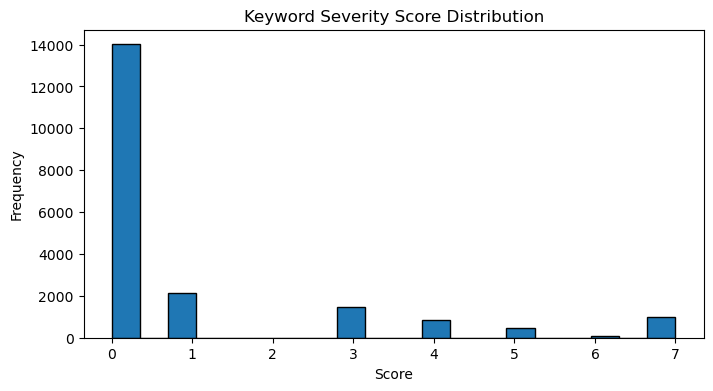

In [9]:
plt.figure(figsize=(8,4))

plt.hist(
    df["Keyword_Score"],
    bins=20,
    edgecolor="black"
)

plt.title("Keyword Severity Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()

In [10]:
def resolution_score(hours):

    if hours <= 12:
        return 3

    elif hours <= 48:
        return 2

    else:
        return 1

In [11]:
df["Resolution_Score"] = (
    df["Resolution_Time_Hours"]
    .apply(resolution_score)
)

df["Resolution_Score"].value_counts()

Resolution_Score
2    8347
1    6154
3    5499
Name: count, dtype: int64

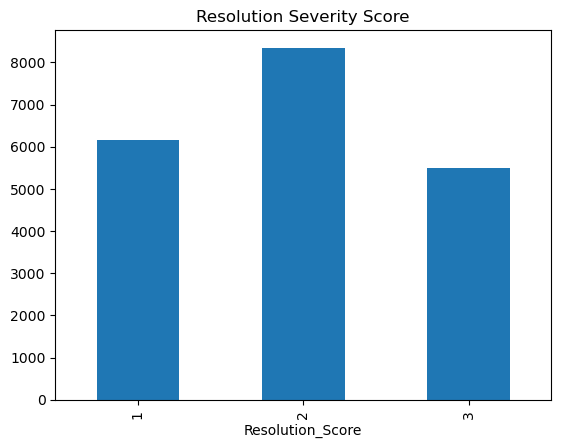

In [12]:
df["Resolution_Score"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Resolution Severity Score")
plt.show()

In [13]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
embeddings = model.encode(
    df["Combined_Text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [15]:
embeddings.shape

(20000, 384)

In [16]:
import numpy as np

np.save(
    "../data/embeddings.npy",
    embeddings
)

In [17]:
embeddings = np.load(
    "../data/embeddings.npy"
)

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

semantic_score = pca.fit_transform(
    embeddings
)

df["Semantic_Score"] = semantic_score

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Semantic_Score"] = scaler.fit_transform(
    df[["Semantic_Score"]]
)

In [20]:
df["Semantic_Score"].describe()

count    20000.000000
mean         0.510892
std          0.249556
min          0.000000
25%          0.252540
50%          0.534936
75%          0.726587
max          1.000000
Name: Semantic_Score, dtype: float64

In [21]:
df["Final_Severity_Score"] = (
    0.5 * df["Semantic_Score"]
    + 0.3 * (
        df["Keyword_Score"]
        / df["Keyword_Score"].max()
    )
    + 0.2 * (
        df["Resolution_Score"]
        / 3
    )
)

In [22]:
type(embeddings)

numpy.ndarray

In [23]:
len(embeddings)

20000

In [24]:
embeddings[:2]

array([[ 1.57210920e-02, -1.44378059e-02,  4.82178442e-02,
         3.22405957e-02, -1.64683610e-02, -2.09573973e-02,
        -5.36986999e-03, -1.25699267e-02, -4.50087823e-02,
        -2.23189890e-02, -2.47047283e-04,  1.74839646e-02,
        -2.20949166e-02,  3.61962360e-03,  3.92044298e-02,
         1.99735258e-02,  3.95510942e-02, -1.09695494e-01,
        -7.38048926e-02, -4.18320298e-02,  5.86172566e-02,
        -1.01456344e-02, -7.87057728e-03,  5.03520966e-02,
         8.77876114e-03, -1.73508879e-02, -2.22589877e-02,
         8.79695714e-02, -8.87688808e-03, -6.06693253e-02,
        -3.74385575e-03, -1.75304469e-02,  1.14193164e-01,
         2.77714562e-02,  8.93371552e-02,  9.04014781e-02,
         6.05944879e-02, -3.00263967e-02,  5.13134822e-02,
        -7.27317436e-03,  2.59800795e-02, -5.28733619e-02,
         2.70286370e-02,  6.12795763e-02, -2.18163594e-03,
         4.06178311e-02, -3.83385480e-03, -3.63909341e-02,
         6.67247921e-02,  4.30992767e-02,  3.90286632e-0

In [25]:
df["Keyword_Score_Normalized"] = (
    df["Keyword_Score"]
    / df["Keyword_Score"].max()
)

df["Resolution_Score_Normalized"] = (
    df["Resolution_Score"]
    / 3
)

df["Final_Severity_Score"] = (
    0.5 * df["Semantic_Score"]
    + 0.3 * df["Keyword_Score_Normalized"]
    + 0.2 * df["Resolution_Score_Normalized"]
)

In [26]:
df["Final_Severity_Score"].describe()

count    20000.000000
mean         0.428797
std          0.138740
min          0.082435
25%          0.336700
50%          0.425614
75%          0.511279
max          0.905220
Name: Final_Severity_Score, dtype: float64

In [27]:
def infer_severity(score):

    if score < 0.25:
        return "Low"

    elif score < 0.50:
        return "Medium"

    elif score < 0.75:
        return "High"

    else:
        return "Critical"

In [28]:
df["Inferred_Severity"] = (
    df["Final_Severity_Score"]
    .apply(infer_severity)
)

In [29]:
df["Inferred_Severity"].value_counts()

Inferred_Severity
Medium      12477
High         5082
Low          1924
Critical      517
Name: count, dtype: int64

In [30]:
df["Mismatch_Label"] = (
    df["Priority_Level"]
    !=
    df["Inferred_Severity"]
).astype(int)

In [31]:
def mismatch_type(row):

    order = {
        "Low":1,
        "Medium":2,
        "High":3,
        "Critical":4
    }

    assigned = order[row["Priority_Level"]]
    inferred = order[row["Inferred_Severity"]]

    if inferred > assigned:
        return "Hidden Crisis"

    elif inferred < assigned:
        return "False Alarm"

    return "Consistent"

df["Mismatch_Type"] = df.apply(
    mismatch_type,
    axis=1
)

In [32]:
df["Final_Severity_Score"].describe()

count    20000.000000
mean         0.428797
std          0.138740
min          0.082435
25%          0.336700
50%          0.425614
75%          0.511279
max          0.905220
Name: Final_Severity_Score, dtype: float64

In [33]:
q1 = df["Final_Severity_Score"].quantile(0.35)
q2 = df["Final_Severity_Score"].quantile(0.70)
q3 = df["Final_Severity_Score"].quantile(0.90)

print(q1, q2, q3)

0.3742860759298007 0.4917384874820709 0.5983123488937105


In [34]:
def infer_severity(score):

    if score < q1:
        return "Low"

    elif score < q2:
        return "Medium"

    elif score < q3:
        return "High"

    else:
        return "Critical"

In [35]:
df["Inferred_Severity"] = (
    df["Final_Severity_Score"]
    .apply(infer_severity)
)

df["Inferred_Severity"].value_counts()

Inferred_Severity
Medium      7000
Low         7000
High        4000
Critical    2000
Name: count, dtype: int64

In [37]:
df["Mismatch_Label"] = (
    df["Priority_Level"] !=
    df["Inferred_Severity"]
).astype(int)

df["Mismatch_Label"].value_counts()

Mismatch_Label
1    14318
0     5682
Name: count, dtype: int64

In [38]:
priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

def mismatch_type(row):

    assigned = priority_map[row["Priority_Level"]]
    inferred = priority_map[row["Inferred_Severity"]]

    if inferred > assigned:
        return "Hidden Crisis"

    elif inferred < assigned:
        return "False Alarm"

    else:
        return "Consistent"

df["Mismatch_Type"] = df.apply(
    mismatch_type,
    axis=1
)

In [39]:
df["Mismatch_Type"].value_counts()

Mismatch_Type
Hidden Crisis    7809
False Alarm      6509
Consistent       5682
Name: count, dtype: int64

In [40]:
df["Severity_Delta"] = (
    df["Inferred_Severity"].map(priority_map)
    -
    df["Priority_Level"].map(priority_map)
)

df["Severity_Delta"].describe()

count    20000.000000
mean         0.135200
std          1.345218
min         -3.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: Severity_Delta, dtype: float64

In [41]:
df.to_csv(
    "../data/pseudo_labeled_tickets.csv",
    index=False
)

In [43]:
def mismatch_type(row):

    delta = row["Severity_Delta"]

    if delta >= 2:
        return "Hidden Crisis"

    elif delta <= -2:
        return "False Alarm"

    else:
        return "Consistent"

df["Mismatch_Type"] = df.apply(
    mismatch_type,
    axis=1
)

In [44]:
df["Mismatch_Label"] = (
    abs(df["Severity_Delta"]) >= 2
).astype(int)

df["Mismatch_Label"].value_counts()

Mismatch_Label
0    14559
1     5441
Name: count, dtype: int64

In [45]:
df["Mismatch_Type"] = df.apply(
    mismatch_type,
    axis=1
)

df["Mismatch_Type"].value_counts()

Mismatch_Type
Consistent       14559
Hidden Crisis     3202
False Alarm       2239
Name: count, dtype: int64

In [46]:
## Pseudo-Label Generation Strategy

#Rather than treating every difference between the inferred severity and the assigned priority as a mismatch, a tolerance margin was introduced.

#A ticket is considered a genuine mismatch only when the inferred severity differs from the assigned priority by two or more severity levels.

#Examples:
#
# Low → Medium : Consistent
#- Medium → High : Consistent
#- High → Critical : Consistent
#- Low → High : Hidden Crisis
#- Low → Critical : Hidden Crisis
#- Critical → Medium : False Alarm
#- Critical → Low : False Alarm

#This design reduces the impact of minor annotation variability and focuses the model on identifying substantial priority inconsistencies.

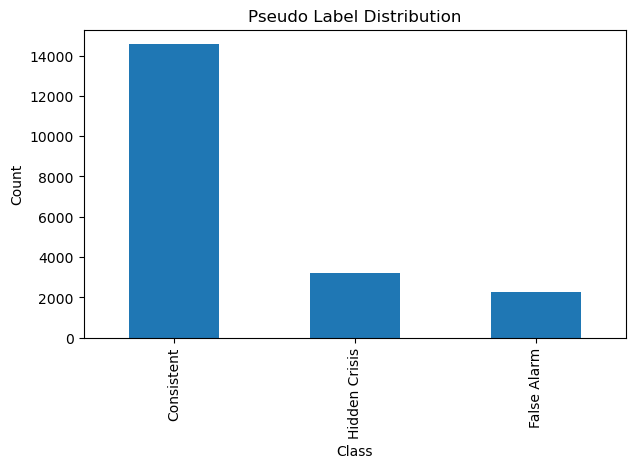

In [47]:
plt.figure(figsize=(7,4))

df["Mismatch_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Pseudo Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

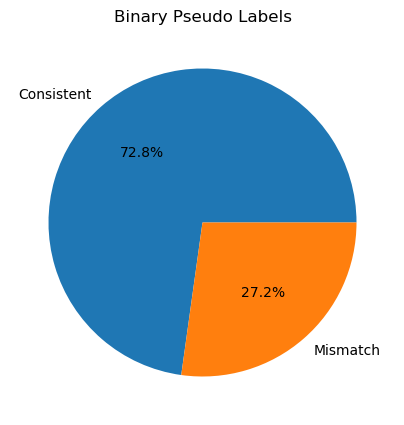

In [48]:
plt.figure(figsize=(5,5))

df["Mismatch_Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Consistent","Mismatch"]
)

plt.ylabel("")
plt.title("Binary Pseudo Labels")

plt.show()

In [49]:
df.to_csv(
    "../data/pseudo_labeled_tickets.csv",
    index=False
)